In [1]:
from utils_somecor import *
from prep_traindata import *
from prep_somconfig import *
from prep_somclass import *
from prep_ecoregion import *

In [2]:
def setup_experiment(task_control_dict, root_io_dict, topology, percentile, rseed=None, trial=None):
    #------------------------------------
    # retrieve task controller
    #------------------------------------
    isecor = task_control_dict['isecor']

    #------------------------------------
    # retrieve root io setting
    #------------------------------------
    ROOT_SAVE_DIR = root_io_dict['ROOT_SAVE_DIR']
    ROOT_FIGS_DIR = root_io_dict['ROOT_FIGS_DIR']
    
    #------------------------------------
    # if rseed not specified, generate a random integer between 1 and 100
    #------------------------------------
    if rseed is None:
        #------------------------------------
        # Control the SOM random generator with random seeding option.
        # For further information, see https://github.com/rileypsmith/sklearn-som
        #------------------------------------
        rseed=random.randint(1,100)
        
    #------------------------------------
    # setup experiment configurations
    #------------------------------------

    #-- trial ID
    if trial is None:
        trial=rseed

    #-- percentile threshold for regionalization
    if not isecor:
        percentile = 0

    #------------------------------------
    # register SOM input parameters
    #------------------------------------
    #-- number of SOM classes
    mdim, ndim = map(int,topology.split('x'))
    nclss=mdim*ndim 

    #-- model configurations to be used "as it is"
    name_config_list  = ['dpth','lats','lonx','lony']
    isuse_config_list = [True  ,True  ,False ,False ]

    #-- model variables to be used "as it is" (parameters)
    name_parameters_list  = ['chlmaxday']
    isuse_parameters_list = [True       ]

    #-- model variables for annual mean and seasonal change
    name_variables_list  = ['temp','salin','mix_dpth','light_pa','chla']
    isuse_variables_list = [True  ,True   ,True      ,True      ,True  ]

    #-- count number of parameters
    pdim = sum(isuse_config_list) + sum(isuse_parameters_list) + 2 * sum(isuse_variables_list)

    #------------------------------------
    # experiment I/O settings
    #------------------------------------
    PATH_DATA = f"{ROOT_SAVE_DIR}{topology}/{percentile:02d}/{trial:02d}/"
    PATH_FIGS = f"{ROOT_FIGS_DIR}{topology}/{percentile:02d}/{trial:02d}/"

    #------------------------------------
    # register experiment configurations to a dictionary
    #------------------------------------
    exp_config_dict = {
        'trial': trial, 
        'rseed': rseed, 
        'mdim': mdim,
        'ndim': ndim,
        'nclss': nclss,
        'pdim': pdim,
        'topology': topology,
        'percentile': percentile,
        'name_config_list'     : name_config_list, 
        'name_parameters_list' : name_parameters_list, 
        'name_variables_list'  : name_variables_list, 
        'isuse_config_list'    : isuse_config_list, 
        'isuse_parameters_list': isuse_parameters_list, 
        'isuse_variables_list' : isuse_variables_list, 
        'PATH_DATA': PATH_DATA,
        'PATH_FIGS': PATH_FIGS,
    }

    return exp_config_dict

In [3]:
def prep_traindata(root_io_dict, task_control_dict, exp_config_dict):
    isdebug       = task_control_dict['isdebug']
    issomtrd_save = task_control_dict['issomtrd_save']
    
    #-------------------------------------
    # prepare SOM training data
    #-------------------------------------

    file_trdat = "som_traindata.pkl"

    #------------------------------------
    # SOM training data in a dictionary
    #------------------------------------
    if issomtrd_save:
        traindata_dict = save_traindata(root_io_dict,exp_config_dict,file_trdat)
    else:
        traindata_dict = load_traindata(root_io_dict,file_trdat)

    if isdebug:
        inspect_dictionary(traindata_dict)

    return traindata_dict

In [4]:
def prep_somclss_2D(root_io_dict,task_control_dict,exp_config_dict,traindata_dict):
    issom_smth = task_control_dict['issom_smth']
    issom_cls  = task_control_dict['issom_cls']
    
    #-------------------------------------
    # prepare SOM classes mapped on 2D grid
    #-------------------------------------

    if issom_smth:
        file_somclss = "somclss_2D_smthd.pkl"
        file_somclss_nc = "TP2_clss_smthd.nc"
    else:    
        file_somclss = "somclss_2D.pkl"
        file_somclss_nc = "TP2_clss.nc"

    #-------------------------------------
    # SOM classes in a dictionary
    #-------------------------------------
    if issom_cls:
        somclss_2D_dict = som_clssification_2D(task_control_dict,traindata_dict,exp_config_dict,file_somclss)
    else:
        somclss_2D_dict = load_somclss_2D(root_io_dict,file_somclss)

    #-------------------------------------
    # save SOM classes to a netcdf file
    #-------------------------------------
    save_som_dict_to_ncfile(somclss_2D_dict,exp_config_dict,vardict='clss_mskd_ma',varname='class',file_nc=file_somclss_nc)

    return somclss_2D_dict

In [5]:
def plot_somclss_2D_dict(task_control_dict, exp_config_dict, somclss_2D_dict):
    #-------------------------------------
    # plot SOM classes on TP2 domain from dictionary
    #-------------------------------------
    issom_smth = task_control_dict['issom_smth']
    
    #-- retrieve SOM input settings from a dictionary
    trial     = exp_config_dict['trial']
    topology  = exp_config_dict['topology']
    PATH_FIGS = exp_config_dict['PATH_FIGS']
    PATH_DATA = exp_config_dict['PATH_DATA']

    #-- figure title and file name

    if issom_smth:
        title=f"TP2 som classes smoothed: {topology}/{trial:02d}"
        outfile=f"{PATH_FIGS}TP2_clss_smthd_{topology}_{trial:02d}.png"
    else:
        title=f"TP2 som classes: {topology}/{trial:02d}"
        outfile=f"{PATH_FIGS}TP2_clss_{topology}_{trial:02d}.png"
    
    #-- plot a figure
    fig, ax = plt.subplots(1, 1, figsize=(5,4))
    plot_som_dict(ax,somclss_2D_dict,title)
    plt.tight_layout()

    #-- save a figure
    directory_path = Path(PATH_FIGS)
    try:
        directory_path.mkdir(parents=True, exist_ok=True)
        print(f"Directories '{directory_path}' created")
    except OSError as error:
        print(f"Error creating directories '{directory_path}': {error}")

    plt.savefig(outfile, dpi=300, bbox_inches='tight')

    print(f"{outfile} is saved")
    plt.show()

In [6]:
def plot_som_clss_nc(exp_config_dict):
    #-------------------------------------
    # plot SOM classes on TP2 domain from netcdf file
    #-------------------------------------
    topology  = exp_config_dict['topology']
    trial     = exp_config_dict['trial']
    PATH_DATA = exp_config_dict['PATH_DATA']
    
    #-------------------------------------------
    # plot SOM classes read from nc files
    #-------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    file_path = f"{PATH_DATA}TP2_clss.nc"
    title=f"TP2 som classes: {topology}/{trial:02d}"
    plot_som_ncfile(axes[0],file_path,title) 
    
    file_path = f"{PATH_DATA}TP2_clss_smthd.nc"
    title=f"TP2 som classes smoothed: {topology}/{trial:02d}"
    plot_som_ncfile(axes[1],file_path,title) 

    plt.tight_layout()
    plt.show()

In [7]:
def prep_somecor_2D_dict(task_control_dict,exp_config_dict,somclss_2D_dict):
    #---------------------------------
    # Regionalization of SOM classified regions (SOMECOR)
    #---------------------------------
    topology   = exp_config_dict['topology']
    percentile = exp_config_dict['percentile']
    trial      = exp_config_dict['trial']
    PATH_DATA  = exp_config_dict['PATH_DATA']
    PATH_FIGS  = exp_config_dict['PATH_FIGS']

    isplot_map = task_control_dict['isplot_map']
    
    #-- regionalize SOM classes on a 2D map
    ecor_2D_dict = som_regionalization(task_control_dict,exp_config_dict,somclss_2D_dict)

    #-- save ecoregion to netcdf file
    file_nc = "TP2_ecor.nc"
    save_som_dict_to_ncfile(ecor_2D_dict,exp_config_dict,vardict='ecor_mskd_ma',varname='ecoregion',file_nc=file_nc)

    if isplot_map:
        #-- plot ecoregions on TP2 domain from a nc file
        fig, ax = plt.subplots(1, 1, figsize=(6,5))

        file_path = f"{PATH_DATA}TP2_ecor.nc"
        title = f"TP2 ecoregions: {topology}/{percentile:02d}/{trial:02d}"
        plot_ecor_ncfile(ax,file_path,title)

        #-- save a figure
        directory_path = Path(PATH_FIGS)
        try:
            directory_path.mkdir(parents=True, exist_ok=True)
            print(f"Directories '{directory_path}' created")
        except OSError as error:
            print(f"Error creating directories '{directory_path}': {error}")

        outfile = f"{PATH_FIGS}TP2_ecor_{topology}_{percentile:02d}_{trial:02d}.png"
        plt.savefig(outfile, dpi=300, bbox_inches='tight')
        print(f"{outfile} is saved")
        plt.show()

    return ecor_2D_dict

In [8]:
def prep_expconfig(rseed):
    #------------------------------------
    # register root I/O directories
    #------------------------------------

    ROOT_LOAD_DIR  = '../input/'     # root folder for loading a file
    ROOT_SAVE_DIR = '../output/SOM/' # root folder for saving a file
    #ROOT_SAVE_DIR = '/root/projects/TP2SOM/data/'   # root folder for saving a figures
    #ROOT_FIGS_DIR = '../figs/SOM/'   # root folder for saving a figures
    ROOT_FIGS_DIR = '/root/projects/TP2SOM/figs/'   # root folder for saving a figures

    root_io_dict = {
    'ROOT_LOAD_DIR': ROOT_LOAD_DIR, 
    'ROOT_SAVE_DIR': ROOT_SAVE_DIR, 
    'ROOT_FIGS_DIR': ROOT_FIGS_DIR
    }

    #------------------------------------
    # register task controllers (boolean)
    #------------------------------------

    isdebug       = False # print extra array inspection
    isplot        = False # plot 2D array with imshow
    isplot_map    = True # plot 2D map with basemap projection
    isplot_hst    = True # plot histogram for ecoregionalization
    isconfig_save = True  # prepare a dictionary of experiment settings and save pickle file
    issomtrd_save = False # prepare SOM training data and save pickle file
    issom_rnd     = True  # perform random sampling on training data
    issom_cls     = True  # perform SOM classification and save pickle file
    issom_smth    = True  # perform 2D smoothing on 2D SOM class.
    isecor        = True  # perform ecoregionalization over SOM classes

    #-- register task controllers to a dictionary

    task_control_dict = {
    'isdebug'    : isdebug,
    'isplot'     : isplot,
    'isplot_map' : isplot_map,
    'isplot_hst' : isplot_hst,
    'isconfig_save' : isconfig_save,
    'issomtrd_save' : issomtrd_save,
    'issom_rnd'  : issom_rnd,
    'issom_cls'  : issom_cls,
    'issom_smth' : issom_smth,
    'isecor'     : isecor
    }

    #-- SOM topology [mdim x ndim] and ecoregionalization threshold [%]
    #topology, percentile = "8x8", 80
    #topology, percentile = "4x3", 90
    topology, percentile = "4x3", 85
    #topology, percentile = "3x4", 85
    #topology, percentile = "3x3", 95
    #topology, percentile = "2x3", 99
    #topology, percentile = "5x3", 90
    
    if isconfig_save:
        exp_config_dict = save_somconfig(task_control_dict, root_io_dict, setup_experiment, topology, percentile, rseed)
    else:
        exp_config_dict = load_somconfig(root_io_dict, trial)

    if isdebug:
        inspect_dictionary(task_control_dict)
        inspect_dictionary(exp_config_dict)

    return root_io_dict, task_control_dict, exp_config_dict

Trial: 74
Directories '../output/SOM/4x3/85/74' created
SOM config file: ../output/SOM/4x3/85/74/SOM_config.yaml saved
SOM training data file: '../output/SOM/som_traindata.pkl' loaded
----------------------------------
 Concatenate SOM inputs
----------------------------------
dpth
lats
chlmaxday
ann_temp
ann_salin
ann_mix_dpth
ann_light_pa
ann_chla
dlt_temp
dlt_salin
dlt_mix_dpth
dlt_light_pa
dlt_chla
----------------------------------
 Perform SOM classification
----------------------------------
Trial ID            : 74
SOM topology        : 4x3
Number of parameters: 13
----------------------------------
 Apply 2D smoothing to SOM classes on 2D grid
----------------------------------
Number of iterations: 30
Directories '../output/SOM/4x3/85/74' created
SOM classes data file: '../output/SOM/4x3/85/74/somclss_2D_smthd.pkl' saved
../output/SOM/4x3/85/74/TP2_clss_smthd.nc is saved.
Cutoff index: 27, Cutoff value: 634
<class 'numpy.int64'> 634
<class 'numpy.int64'> 634


/root/miniconda3/envs/jnote/lib/python3.11/site-packages/skimage/measure/_label.py:125: RuntimeWarning: invalid value encountered in cast
  return clabel(label_image, background, return_num, connectivity)


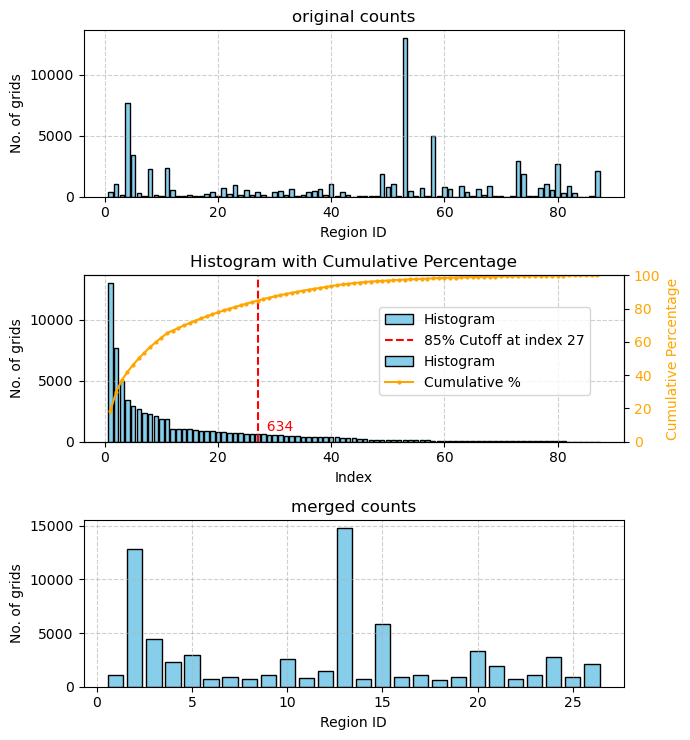

../output/SOM/4x3/85/74/TP2_ecor.nc is saved.
../output/SOM/4x3/85/74/TP2_ecor.nc is loaded.
1.0 26.0
Directories '/root/projects/TP2SOM/figs/4x3/85/74' created
/root/projects/TP2SOM/figs/4x3/85/74/TP2_ecor_4x3_85_74.png is saved


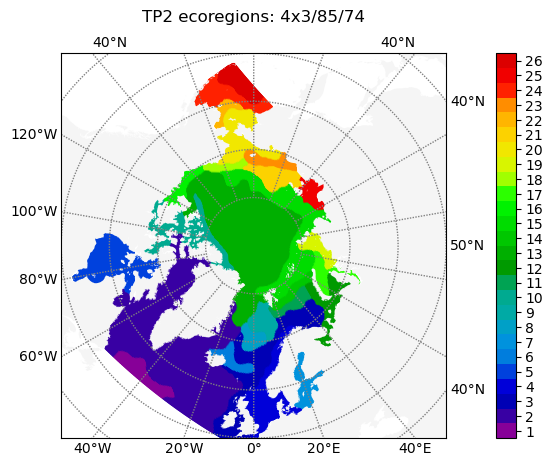

number of classes: 12
Directories '/root/projects/TP2SOM/figs/4x3/85/74' created
/root/projects/TP2SOM/figs/4x3/85/74/TP2_clss_smthd_4x3_74.png is saved


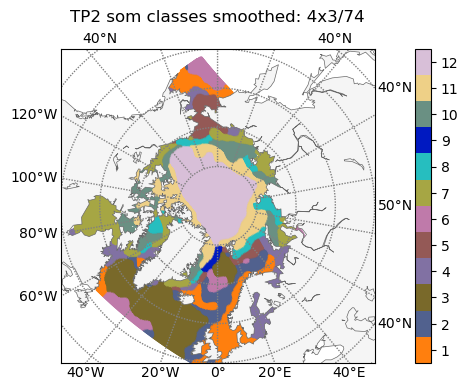

FileNotFoundError: [Errno 2] No such file or directory: b'../output/SOM/4x3/85/74/TP2_clss.nc'

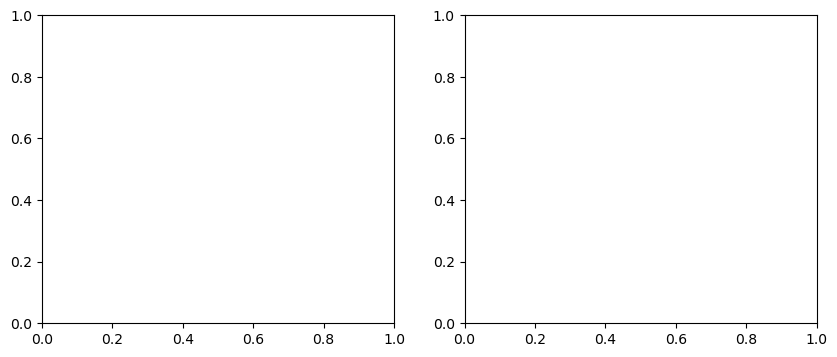

In [9]:
#------------------------------------------
#  
#------------------------------------------
for rseed in range(74, 75):
    print(f"Trial: {rseed:02d}")
    root_io_dict, task_control_dict, exp_config_dict = prep_expconfig(rseed)
    traindata_dict                                   = prep_traindata (root_io_dict, task_control_dict, exp_config_dict)
    somclss_2D_dict                                  = prep_somclss_2D(root_io_dict, task_control_dict, exp_config_dict, traindata_dict)
    ecor_2D_dict                                     = prep_somecor_2D_dict(task_control_dict,exp_config_dict,somclss_2D_dict)

    isplot_map = task_control_dict['isplot_map']
    if isplot_map:
        plot_somclss_2D_dict(task_control_dict, exp_config_dict, somclss_2D_dict)
        plot_som_clss_nc(exp_config_dict)